# Chapter 7: Non-Euclidean Geometry

**Source orientation:** Hartshorne, *Geometry: Euclid and Beyond*, Chapter 7, printed pages 295-434 (PDF pages 307-446), sections 33-43. The source span was inspected through rendered chapter pages and used only for orientation: section order, terminology, theorem route, and the computational objects below. The prose, diagrams, code, checks, and examples here are original course material.

**Chapter question:** How can a geometry deny Euclid's parallel postulate and still behave like a coherent plane with lines, congruence, distance, area, and trigonometry?

**Chapter goal:** Build a computational model of the chapter's path from neutral geometry to hyperbolic geometry. The notebook separates three layers: axioms that remain neutral, model predicates that replace the parallel postulate, and metric invariants that survive inversion and Poincare-model isometries.

## Computational Translation Guide

| Chapter idea | Computational object | What we inspect |
| --- | --- | --- |
| Parallel postulate | branch choice in a proof-state graph | whether one line through a point is parallel, or two limiting directions appear |
| Neutral geometry | dependencies that avoid the parallel postulate | which conclusions survive before Euclidean or hyperbolic choice |
| Angle defect | `pi - (A + B + C)` for a Poincare triangle | positive defect as both non-Euclidean signal and area |
| Circle inversion | `P -> O + r^2(P-O)/||P-O||^2` | involution, reciprocal radii, and circle/line behavior |
| Poincare disk geodesic | Euclidean diameter or circle orthogonal to the unit boundary | boundary-orthogonality residual and conformal angle measurement |
| Half-plane geodesic | vertical ray or semicircle orthogonal to the real axis | Cayley transform agrees with disk distance |
| Ends | ideal boundary coordinates and endpoint pairs of geodesics | translations/dilations act on boundary coordinates like field operations |
| Hyperbolic distance | disk or half-plane metric formula | rotation/Cayley invariance and logarithmic vertical distance |
| Hyperbolic trigonometry | `sinh`/`cosh` identities for side lengths and angles | numerical residuals for the cosine law and right-triangle formulas |

## Route Through Sections 33-43

1. Sections 33-36: the parallel-postulate problem, neutral geometry, Archimedean neutral geometry, and the appearance of area through angle defect.
2. Sections 37-38: circle inversion and circle constructions as the Euclidean technology that makes the Poincare model practical.
3. Sections 39-40: the Poincare disk, half-plane geodesics, limiting parallels, and hyperbolic distance.
4. Section 41: ends as ideal boundary data carrying arithmetic.
5. Sections 42-43: hyperbolic trigonometry and the classification viewpoint for Hilbert planes.

## Visualization Storyboard Implemented

| Visual | Library route | Inspection target | Validation |
| --- | --- | --- | --- |
| Neutral branch and angle-defect ledger | NetworkX + Matplotlib | proof dependencies and the strict drop below `pi` | all sampled defects are positive |
| Inversion and geodesic model panel | NumPy + Matplotlib | inversion pairs, disk arcs, half-plane arcs, triangle defect | inversion, orthogonality, Cayley, and trig residuals |
| Poincare geodesic slider | Plotly HTML | how the center and curvature of a disk geodesic move with the endpoint | boundary orthogonality and distance values |
| Ends and angle-of-parallelism lab | Plotly HTML + SymPy | endpoint arithmetic, dilations, and `Pi(d)` | exact `tan(Pi/2)=exp(-d)` identity and numeric samples |
| Applied triangle lab | Pandas + JSON/CSV | side/angle/area/trig data for modifiable triangles | cosine law and right-triangle residuals |


In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Euclid and Beyond book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.hyperbolic import geodesic_arc_points, geodesic_circle, invert_in_circle, poincare_distance
from utils.plotting import PALETTE, draw_circle, draw_segment, label_point, set_equal_axes

UNIT = "chapter-07"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
FIGURES = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE = UNIT_ARTIFACT_ROOT / "interactive"
TABLES = UNIT_ARTIFACT_ROOT / "tables"
CHECKS = UNIT_ARTIFACT_ROOT / "checks"
for folder in [FIGURES, INTERACTIVE, TABLES, CHECKS]:
    folder.mkdir(parents=True, exist_ok=True)

artifact_records = []


def record_artifact(path, concept, min_bytes=512):
    path = assert_artifact(path, min_bytes=min_bytes)
    if not path.resolve().is_relative_to(UNIT_ARTIFACT_ROOT.resolve()):
        raise AssertionError(f"Artifact escaped chapter-07 subtree: {path}")
    record = {
        "concept": concept,
        "path": path.relative_to(BOOK_ROOT).as_posix(),
        "bytes": path.stat().st_size,
    }
    artifact_records.append(record)
    return path


source_span = {
    "book": "Hartshorne, Geometry: Euclid and Beyond",
    "chapter": "7 Non-Euclidean Geometry",
    "printed_pages": "295-434",
    "pdf_pages": "307-446",
    "sections": "33-43",
    "source_use": "orientation only; no copied prose, screenshots, crops, figures, or exercises",
}
source_span_path = save_json(source_span, UNIT, "checks", "source-span.json", root=ARTIFACT_ROOT)
record_artifact(source_span_path, "source span record", min_bytes=128)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


## Geometry Primitives Used Throughout

The next cell exposes the mathematical inputs rather than hiding them inside a chapter generator. The disk model uses the unit circle as its ideal boundary. A geodesic is either a diameter or a Euclidean circle whose center `C` and radius `R` satisfy `||C||^2 - R^2 = 1`. The upper half-plane model is connected to the disk by the Cayley transform `z -> (z-i)/(z+i)`, so a distance computed in one model should match the other.


In [2]:
def unit_boundary(samples=400):
    theta = np.linspace(0.0, 2.0 * np.pi, samples)
    return np.column_stack([np.cos(theta), np.sin(theta)])


def complex_to_point(z):
    return np.array([float(np.real(z)), float(np.imag(z))])


def point_to_complex(p):
    p = np.asarray(p, dtype=float)
    return complex(float(p[0]), float(p[1]))


def halfplane_to_disk(z):
    z = np.asarray(z, dtype=complex)
    return (z - 1j) / (z + 1j)


def disk_to_halfplane(w):
    w = np.asarray(w, dtype=complex)
    return 1j * (1.0 + w) / (1.0 - w)


def halfplane_distance(z, w):
    z, w = complex(z), complex(w)
    arg = 1.0 + abs(z - w) ** 2 / (2.0 * z.imag * w.imag)
    return float(math.acosh(max(1.0, arg)))


def disk_distance_via_cayley(a, b):
    za = disk_to_halfplane(point_to_complex(a))
    zb = disk_to_halfplane(point_to_complex(b))
    return halfplane_distance(za, zb)


def circle_orthogonality_residual(center, radius):
    if center is None or radius is None:
        return 0.0
    return abs(float(np.dot(center, center)) - radius * radius - 1.0)


def tangent_direction_at(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    center, radius = geodesic_circle(p, q)
    if center is None:
        v = q - p
    else:
        radial = p - center
        v = np.array([-radial[1], radial[0]])
        if np.dot(v, q - p) < 0:
            v = -v
    return v / np.linalg.norm(v)


def angle_between(u, v):
    u = np.asarray(u, dtype=float) / np.linalg.norm(u)
    v = np.asarray(v, dtype=float) / np.linalg.norm(v)
    return float(math.acos(np.clip(float(np.dot(u, v)), -1.0, 1.0)))


def triangle_measure(vertices):
    A, B, C = [np.asarray(p, dtype=float) for p in vertices]
    side_a = poincare_distance(B, C)
    side_b = poincare_distance(A, C)
    side_c = poincare_distance(A, B)
    angle_A = angle_between(tangent_direction_at(A, B), tangent_direction_at(A, C))
    angle_B = angle_between(tangent_direction_at(B, A), tangent_direction_at(B, C))
    angle_C = angle_between(tangent_direction_at(C, A), tangent_direction_at(C, B))
    angle_sum = angle_A + angle_B + angle_C
    defect = math.pi - angle_sum
    residual_a = math.cosh(side_a) - (
        math.cosh(side_b) * math.cosh(side_c)
        - math.sinh(side_b) * math.sinh(side_c) * math.cos(angle_A)
    )
    residual_b = math.cosh(side_b) - (
        math.cosh(side_a) * math.cosh(side_c)
        - math.sinh(side_a) * math.sinh(side_c) * math.cos(angle_B)
    )
    residual_c = math.cosh(side_c) - (
        math.cosh(side_a) * math.cosh(side_b)
        - math.sinh(side_a) * math.sinh(side_b) * math.cos(angle_C)
    )
    return {
        "side_a": side_a,
        "side_b": side_b,
        "side_c": side_c,
        "angle_A": angle_A,
        "angle_B": angle_B,
        "angle_C": angle_C,
        "angle_sum": angle_sum,
        "area_defect": defect,
        "cosine_law_max_abs_residual": max(abs(residual_a), abs(residual_b), abs(residual_c)),
    }


def right_triangle_check(r=0.42, s=0.55):
    C = np.array([0.0, 0.0])
    A = np.array([r, 0.0])
    B = np.array([0.0, s])
    m = triangle_measure([A, B, C])
    a, b, c = m["side_a"], m["side_b"], m["side_c"]
    return {
        "vertices": {"A": A.tolist(), "B": B.tolist(), "C": C.tolist()},
        "right_angle_error": abs(m["angle_C"] - math.pi / 2.0),
        "pythagorean_residual": abs(math.cosh(c) - math.cosh(a) * math.cosh(b)),
        "sine_rule_residual": abs(math.sin(m["angle_A"]) - math.sinh(a) / math.sinh(c)),
        "measurement": m,
    }


sample_pairs = [
    (np.array([-0.45, -0.15]), np.array([0.55, 0.30])),
    (np.array([-0.20, 0.55]), np.array([0.50, -0.35])),
    (np.array([0.00, -0.55]), np.array([0.00, 0.45])),
]
model_checks = []
for a, b in sample_pairs:
    center, radius = geodesic_circle(a, b)
    model_checks.append({
        "a": a.tolist(),
        "b": b.tolist(),
        "orthogonality_residual": circle_orthogonality_residual(center, radius),
        "disk_halfplane_distance_error": abs(poincare_distance(a, b) - disk_distance_via_cayley(a, b)),
    })

pd.DataFrame(model_checks)


,a,b,orthogonality_residual,disk_halfplane_distance_error
0,"[-0.45, -0.15]","[0.55, 0.3]",2.842171e-14,4.440892e-16
1,"[-0.2, 0.55]","[0.5, -0.35]",1.776357e-15,0.000000e+00
2,"[0.0, -0.55]","[0.0, 0.45]",0.000000e+00,0.000000e+00


## Neutral Geometry and the Parallel Decision

The chapter first insists that the parallel postulate is not a casual drawing rule. Neutral geometry keeps incidence, order, congruence, and many triangle facts while withholding the unique-parallel statement. Computationally this is a branch point: the same neutral core can feed a Euclidean model with zero triangle defect or a hyperbolic model with positive defect.

The dependency graph is not a proof of the theorems. It is a proof-state scaffold: inspect which assertions sit before the branch and which assertions become model-specific.


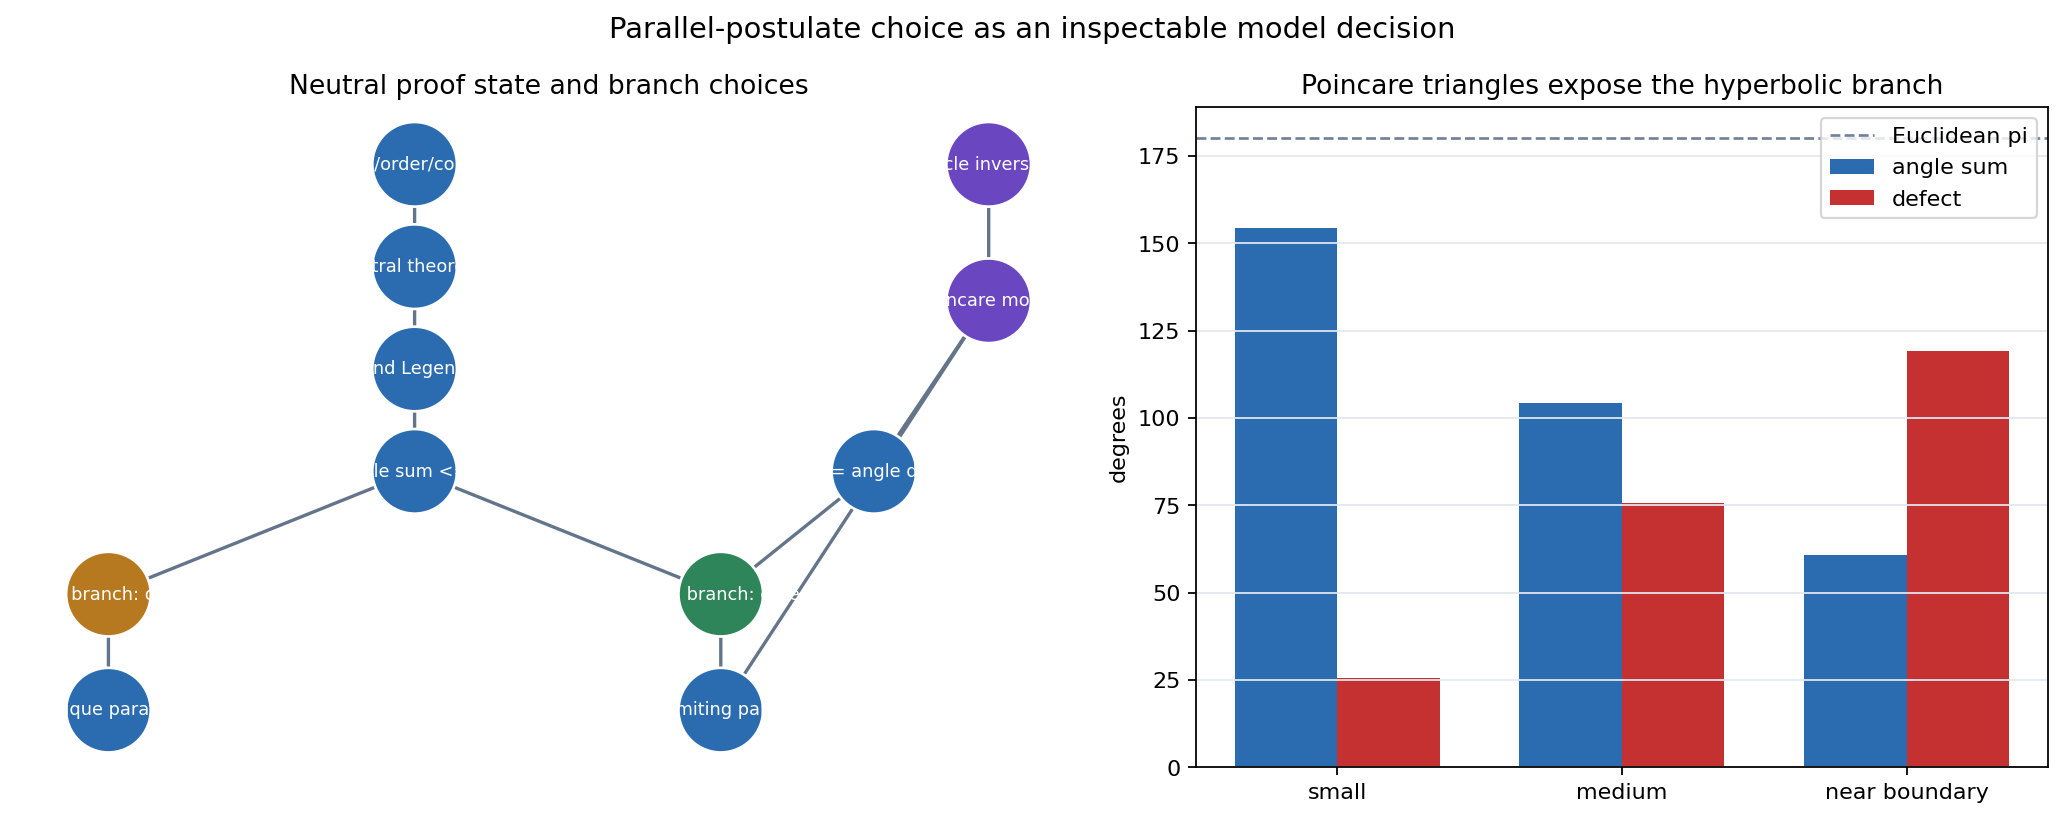

,triangle,angle_sum_degrees,defect_degrees,area_by_defect,cosine_law_residual
0,small,154.341986,25.658014,0.447817,4.440892e-16
1,medium,104.411014,75.588986,1.319277,1.776357e-15
2,near boundary,60.889813,119.110187,2.078865,2.131628e-14


In [3]:
neutral_triangles = {
    "small": [np.array([-0.25, -0.05]), np.array([0.28, 0.12]), np.array([0.02, 0.45])],
    "medium": [np.array([-0.48, -0.25]), np.array([0.52, -0.04]), np.array([-0.10, 0.58])],
    "near boundary": [np.array([-0.72, -0.22]), np.array([0.66, -0.10]), np.array([0.02, 0.78])],
}
neutral_rows = []
for name, verts in neutral_triangles.items():
    m = triangle_measure(verts)
    neutral_rows.append({
        "triangle": name,
        "angle_sum_degrees": math.degrees(m["angle_sum"]),
        "defect_degrees": math.degrees(m["area_defect"]),
        "area_by_defect": m["area_defect"],
        "cosine_law_residual": m["cosine_law_max_abs_residual"],
    })
neutral_df = pd.DataFrame(neutral_rows)

G = nx.DiGraph()
edges = [
    ("incidence/order/congruence", "neutral theorems"),
    ("neutral theorems", "Saccheri and Legendre moves"),
    ("Saccheri and Legendre moves", "angle sum <= pi"),
    ("angle sum <= pi", "Euclidean branch: defect = 0"),
    ("angle sum <= pi", "hyperbolic branch: defect > 0"),
    ("Euclidean branch: defect = 0", "unique parallel"),
    ("hyperbolic branch: defect > 0", "two limiting parallels"),
    ("hyperbolic branch: defect > 0", "area = angle defect"),
    ("circle inversion", "Poincare model"),
    ("Poincare model", "two limiting parallels"),
    ("Poincare model", "area = angle defect"),
]
G.add_edges_from(edges)
node_colors = []
for node in G.nodes:
    if "branch" in node:
        node_colors.append(PALETTE["gold"] if "Euclidean" in node else PALETTE["green"])
    elif node in {"circle inversion", "Poincare model"}:
        node_colors.append(PALETTE["purple"])
    else:
        node_colors.append(PALETTE["blue"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.25, 1.0]})
pos = {
    "incidence/order/congruence": (0, 4),
    "neutral theorems": (0, 3.25),
    "Saccheri and Legendre moves": (0, 2.5),
    "angle sum <= pi": (0, 1.75),
    "Euclidean branch: defect = 0": (-1.6, 0.85),
    "hyperbolic branch: defect > 0": (1.6, 0.85),
    "unique parallel": (-1.6, 0.0),
    "two limiting parallels": (1.6, 0.0),
    "area = angle defect": (2.4, 1.75),
    "circle inversion": (3.0, 4.0),
    "Poincare model": (3.0, 3.0),
}
nx.draw_networkx_edges(G, pos, ax=axes[0], arrows=True, arrowstyle="-|>", arrowsize=14, edge_color="#64748b", width=1.5)
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=node_colors, node_size=1450, edgecolors="white", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=8, font_color="white")
axes[0].set_title("Neutral proof state and branch choices")
axes[0].axis("off")

x = np.arange(len(neutral_df))
axes[1].bar(x - 0.18, neutral_df["angle_sum_degrees"], width=0.36, label="angle sum", color=PALETTE["blue"])
axes[1].bar(x + 0.18, neutral_df["defect_degrees"], width=0.36, label="defect", color=PALETTE["red"])
axes[1].axhline(180.0, color=PALETTE["gray"], linestyle="--", linewidth=1.2, label="Euclidean pi")
axes[1].set_xticks(x, neutral_df["triangle"])
axes[1].set_ylabel("degrees")
axes[1].set_title("Poincare triangles expose the hyperbolic branch")
axes[1].legend(loc="upper right")
axes[1].grid(axis="y", color="#e2e8f0")
fig.suptitle("Parallel-postulate choice as an inspectable model decision", fontsize=13)
fig.tight_layout()
neutral_path = save_matplotlib(fig, UNIT, "figures", "neutral-parallel-branches.png", root=ARTIFACT_ROOT)
plt.close(fig)
record_artifact(neutral_path, "neutral geometry branch graph and angle-defect ledger")

neutral_checks_path = save_json(neutral_rows, UNIT, "checks", "neutral-angle-defects.json", root=ARTIFACT_ROOT)
record_artifact(neutral_checks_path, "neutral triangle angle-defect samples", min_bytes=128)

display_artifact(neutral_path, width=980)
neutral_df


## Circle Inversion as the Bridge to Poincare Lines

Sections 37-39 use circle inversion as the Euclidean mechanism behind the Poincare model. The key computational fact is simple but powerful: inversion is its own inverse, and a circle orthogonal to the inversion circle is preserved as a set. That is why disk geodesics are drawn as Euclidean circular arcs even though their metric is not Euclidean.

Inspect the next panel from left to right: reciprocal points on a ray, disk geodesics orthogonal to the ideal boundary, upper half-plane geodesics, and a hyperbolic triangle whose area is its angle defect.


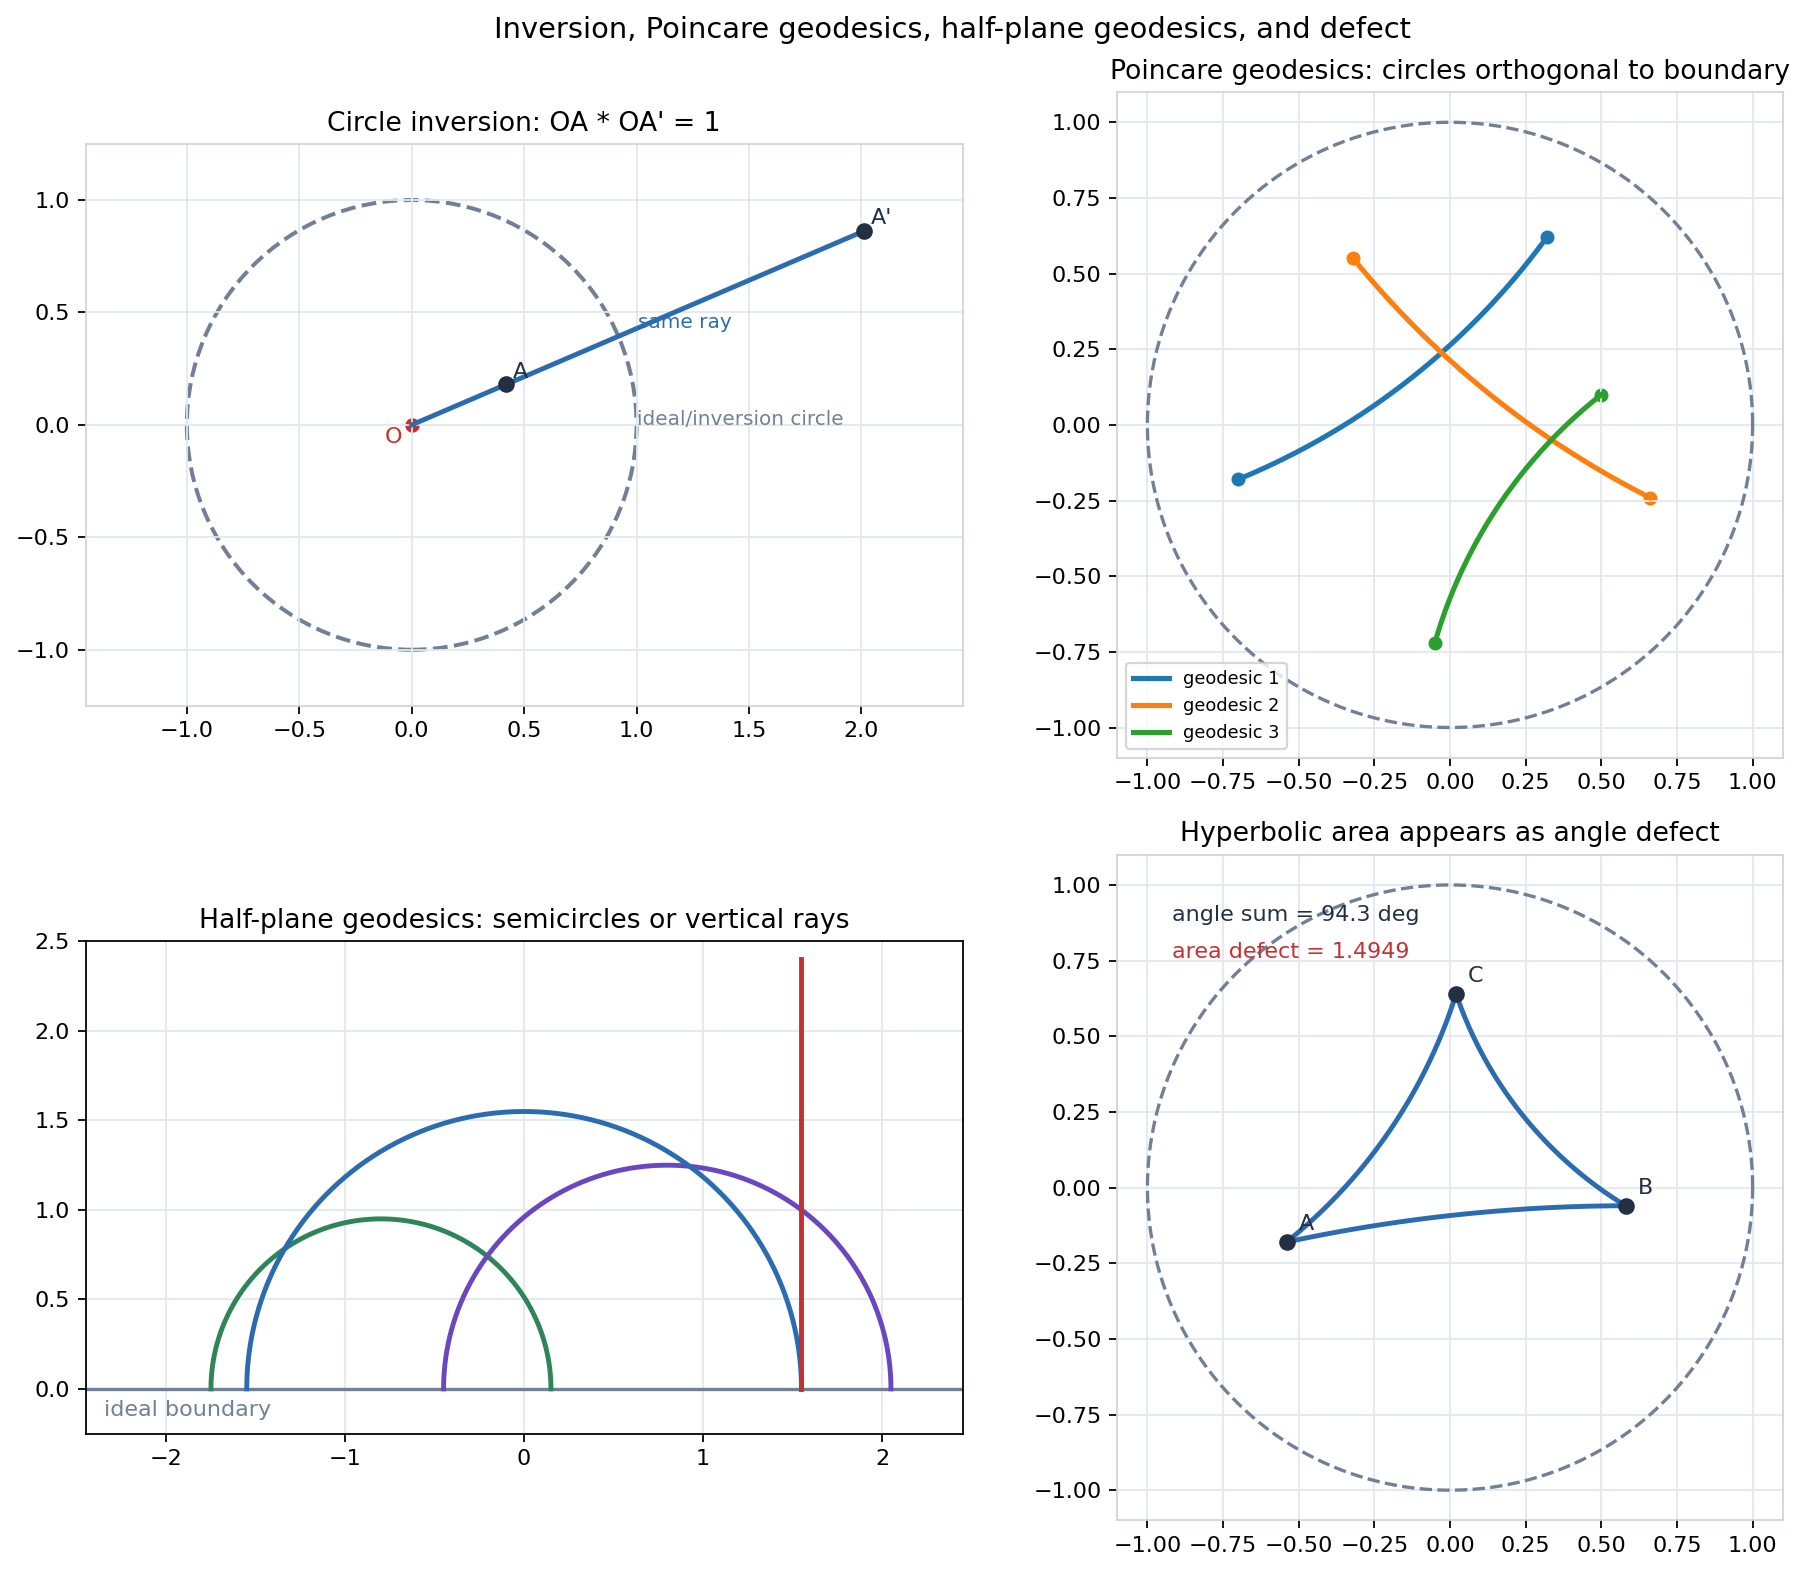

,value
inversion_involution_error,0.000000e+00
inversion_product_error,0.000000e+00
geodesic_orthogonality_max,8.881784e-16
cayley_roundtrip_error,3.140185e-16
cayley_distance_error,2.220446e-16
triangle_area_defect,1.494909e+00
triangle_cosine_law_max_abs_residual,7.993606e-15


In [4]:
A = np.array([0.42, 0.18])
A_inv = invert_in_circle(A)
A_roundtrip = invert_in_circle(A_inv)
inversion_involution_error = float(np.linalg.norm(A_roundtrip - A))
inversion_product_error = abs(float(np.linalg.norm(A) * np.linalg.norm(A_inv)) - 1.0)

disk_pairs = [
    (np.array([-0.70, -0.18]), np.array([0.32, 0.62])),
    (np.array([-0.32, 0.55]), np.array([0.66, -0.24])),
    (np.array([-0.05, -0.72]), np.array([0.50, 0.10])),
]
geo_residuals = []
for a, b in disk_pairs:
    center, radius = geodesic_circle(a, b)
    geo_residuals.append(circle_orthogonality_residual(center, radius))
geodesic_orthogonality_max = max(geo_residuals)

hp_samples = [0.45 + 0.75j, -0.70 + 1.55j, 1.15 + 0.95j]
cayley_roundtrip_error = max(abs(disk_to_halfplane(halfplane_to_disk(z)) - z) for z in hp_samples)
cayley_distance_error = max(
    abs(halfplane_distance(z, w) - poincare_distance(complex_to_point(halfplane_to_disk(z)), complex_to_point(halfplane_to_disk(w))))
    for z, w in [(hp_samples[0], hp_samples[1]), (hp_samples[1], hp_samples[2])]
)

triangle_vertices = [np.array([-0.54, -0.18]), np.array([0.58, -0.06]), np.array([0.02, 0.64])]
triangle_stats = triangle_measure(triangle_vertices)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes[0, 0]
draw_circle(ax, (0, 0), 1, label="ideal/inversion circle", color=PALETTE["gray"], linestyle="--")
draw_segment(ax, (0, 0), A_inv, color=PALETTE["blue"], label="same ray")
label_point(ax, A, "A", offset=(0.03, 0.03))
label_point(ax, A_inv, "A'", offset=(0.03, 0.03))
ax.scatter([0], [0], s=30, color=PALETTE["red"])
ax.text(-0.12, -0.08, "O", color=PALETTE["red"])
ax.set_title("Circle inversion: OA * OA' = 1")
set_equal_axes(ax)
ax.set_xlim(-1.45, 2.45)
ax.set_ylim(-1.25, 1.25)

ax = axes[0, 1]
boundary = unit_boundary()
ax.plot(boundary[:, 0], boundary[:, 1], color=PALETTE["gray"], linestyle="--", linewidth=1.5)
for idx, (a, b) in enumerate(disk_pairs, start=1):
    arc = geodesic_arc_points(a, b, samples=220)
    center, radius = geodesic_circle(a, b)
    ax.plot(arc[:, 0], arc[:, 1], linewidth=2.3, label=f"geodesic {idx}")
    ax.scatter([a[0], b[0]], [a[1], b[1]], s=28)
    if center is not None:
        ax.scatter([center[0]], [center[1]], marker="x", s=36, color=PALETTE["red"])
ax.set_title("Poincare geodesics: circles orthogonal to boundary")
set_equal_axes(ax)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.legend(loc="lower left", fontsize=8)

ax = axes[1, 0]
ax.axhline(0, color=PALETTE["gray"], linewidth=1.5)
for center, radius, color in [(-0.8, 0.95, PALETTE["green"]), (0.8, 1.25, PALETTE["purple"]), (0.0, 1.55, PALETTE["blue"])]:
    theta = np.linspace(0, np.pi, 200)
    ax.plot(center + radius * np.cos(theta), radius * np.sin(theta), color=color, linewidth=2.2)
ax.plot([1.55, 1.55], [0.0, 2.4], color=PALETTE["red"], linewidth=2.2)
ax.text(-2.35, -0.15, "ideal boundary", color=PALETTE["gray"])
ax.set_title("Half-plane geodesics: semicircles or vertical rays")
ax.set_xlim(-2.45, 2.45)
ax.set_ylim(-0.25, 2.5)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, color="#e2e8f0")

ax = axes[1, 1]
ax.plot(boundary[:, 0], boundary[:, 1], color=PALETTE["gray"], linestyle="--")
labels = ["A", "B", "C"]
for p, label in zip(triangle_vertices, labels):
    label_point(ax, p, label)
for a, b in [(triangle_vertices[0], triangle_vertices[1]), (triangle_vertices[1], triangle_vertices[2]), (triangle_vertices[2], triangle_vertices[0])]:
    arc = geodesic_arc_points(a, b, samples=180)
    ax.plot(arc[:, 0], arc[:, 1], color=PALETTE["blue"], linewidth=2.2)
ax.text(-0.92, 0.88, f"angle sum = {math.degrees(triangle_stats['angle_sum']):.1f} deg", color=PALETTE["ink"])
ax.text(-0.92, 0.76, f"area defect = {triangle_stats['area_defect']:.4f}", color=PALETTE["red"])
ax.set_title("Hyperbolic area appears as angle defect")
set_equal_axes(ax)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)

fig.suptitle("Inversion, Poincare geodesics, half-plane geodesics, and defect", fontsize=13)
fig.tight_layout()
inversion_path = save_matplotlib(fig, UNIT, "figures", "poincare-and-inversion-labs.png", root=ARTIFACT_ROOT)
plt.close(fig)
record_artifact(inversion_path, "inversion and Poincare model visual checks")

direct_visual_checks = {
    "inversion_involution_error": inversion_involution_error,
    "inversion_product_error": inversion_product_error,
    "geodesic_orthogonality_max": geodesic_orthogonality_max,
    "cayley_roundtrip_error": float(cayley_roundtrip_error),
    "cayley_distance_error": float(cayley_distance_error),
    "triangle_area_defect": triangle_stats["area_defect"],
    "triangle_cosine_law_max_abs_residual": triangle_stats["cosine_law_max_abs_residual"],
}

display_artifact(inversion_path, width=980)
pd.DataFrame([direct_visual_checks]).T.rename(columns={0: "value"})


## Interactive Poincare Geodesics

A disk geodesic becomes more curved on the page as its endpoints approach the ideal boundary, but its defining invariant does not change: the supporting circle stays orthogonal to the unit circle. Move the slider in the standalone Plotly artifact and inspect the changing endpoint, distance, and arc shape.


In [5]:
fixed_A = np.array([-0.30, 0.18])
angles = np.linspace(-1.15, 1.15, 15)
frame_data = []
for theta in angles:
    moving_B = 0.78 * np.array([math.cos(theta), math.sin(theta)])
    arc = geodesic_arc_points(fixed_A, moving_B, samples=220)
    center, radius = geodesic_circle(fixed_A, moving_B)
    frame_data.append({
        "theta": theta,
        "B": moving_B,
        "arc": arc,
        "distance": poincare_distance(fixed_A, moving_B),
        "orthogonality": circle_orthogonality_residual(center, radius),
    })

boundary = unit_boundary(500)
initial = frame_data[0]
fig = go.Figure(
    data=[
        go.Scatter(x=boundary[:, 0], y=boundary[:, 1], mode="lines", name="ideal boundary", line=dict(color="#64748b", dash="dash")),
        go.Scatter(x=initial["arc"][:, 0], y=initial["arc"][:, 1], mode="lines", name="geodesic arc", line=dict(color="#2b6cb0", width=4)),
        go.Scatter(x=[fixed_A[0]], y=[fixed_A[1]], mode="markers+text", name="fixed A", text=["A"], textposition="top center", marker=dict(size=12, color="#c53030")),
        go.Scatter(x=[initial["B"][0]], y=[initial["B"][1]], mode="markers+text", name="moving B", text=["B"], textposition="top center", marker=dict(size=12, color="#2f855a")),
    ],
    frames=[
        go.Frame(
            name=f"{idx}",
            data=[
                go.Scatter(x=item["arc"][:, 0], y=item["arc"][:, 1], mode="lines", line=dict(color="#2b6cb0", width=4), name="geodesic arc"),
                go.Scatter(x=[item["B"][0]], y=[item["B"][1]], mode="markers+text", text=["B"], textposition="top center", marker=dict(size=12, color="#2f855a"), name="moving B"),
            ],
            traces=[1, 3],
            layout=go.Layout(title_text=f"Poincare geodesic slider: d(A,B)={item['distance']:.3f}, orthogonality residual={item['orthogonality']:.1e}"),
        )
        for idx, item in enumerate(frame_data)
    ],
)
steps = [
    dict(
        method="animate",
        args=[[f"{idx}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
        label=f"{item['theta']:.2f}",
    )
    for idx, item in enumerate(frame_data)
]
fig.update_layout(
    title=f"Poincare geodesic slider: d(A,B)={initial['distance']:.3f}, orthogonality residual={initial['orthogonality']:.1e}",
    xaxis=dict(range=[-1.08, 1.08], scaleanchor="y", zeroline=False),
    yaxis=dict(range=[-1.08, 1.08], zeroline=False),
    height=620,
    sliders=[dict(active=0, steps=steps, currentvalue={"prefix": "boundary angle "})],
    updatemenus=[dict(type="buttons", buttons=[dict(label="play", method="animate", args=[None, {"frame": {"duration": 450, "redraw": True}, "fromcurrent": True}])])],
)
interactive_geodesic_path = save_plotly_html(fig, UNIT, "interactive", "poincare-geodesics.html", root=ARTIFACT_ROOT)
record_artifact(interactive_geodesic_path, "interactive Poincare geodesic slider", min_bytes=2048)

interactive_geodesic_checks = {
    "frame_count": len(frame_data),
    "max_orthogonality_residual": max(item["orthogonality"] for item in frame_data),
    "min_distance": min(item["distance"] for item in frame_data),
    "max_distance": max(item["distance"] for item in frame_data),
}

display_artifact(interactive_geodesic_path, width="100%", height=650)
interactive_geodesic_checks


{'frame_count': 15,
 'max_orthogonality_residual': 5.684341886080802e-14,
 'min_distance': 2.266347299812628,
 'max_distance': 2.8208737073833636}

## Ends and Limiting Parallels

The chapter's arithmetic of ends can be read computationally as arithmetic on ideal boundary coordinates. In the upper half-plane, a geodesic is represented by its boundary endpoint pair. Translations and dilations act on those endpoints, and the vertical distance from `i` to `e^d i` is exactly `d`. This is the multiplicative-to-additive move behind the distance function.

The same section leads to Bolyai's angle of parallelism: if a point is hyperbolic distance `d` from a line, then `tan(Pi(d)/2) = exp(-d)`. The plot makes the limiting behavior inspectable: the farther away the line is, the narrower the parallel cone.


In [6]:
u_symbol = sp.symbols("u", positive=True)
angle_identity = sp.simplify(sp.tan((2 * sp.atan(u_symbol)) / 2) - u_symbol)
assert angle_identity == 0

d_values = np.linspace(0.05, 4.0, 160)
Pi_values = 2.0 * np.arctan(np.exp(-d_values))
angle_parallelism_error = float(np.max(np.abs(np.tan(Pi_values / 2.0) * np.exp(d_values) - 1.0)))
vertical_distance_error = max(abs(halfplane_distance(1j, 1j * math.exp(d)) - d) for d in [0.2, 0.9, 1.7, 3.2])

lambda_values = [0.65, 1.0, 1.55]
base_geodesics = [(-2.0, 0.5), (-1.25, 1.55), (0.2, 2.2)]

fig = make_subplots(rows=1, cols=2, subplot_titles=("Ends as boundary endpoint pairs", "Bolyai angle of parallelism"))
fig.add_trace(go.Scatter(x=[-3.4, 3.4], y=[0, 0], mode="lines", name="ideal boundary", line=dict(color="#64748b", width=2)), row=1, col=1)
for lam in lambda_values:
    for left, right in base_geodesics:
        c = lam * (left + right) / 2.0
        r = lam * (right - left) / 2.0
        theta = np.linspace(0, np.pi, 160)
        x = c + r * np.cos(theta)
        y = r * np.sin(theta)
        fig.add_trace(go.Scatter(x=x, y=y, mode="lines", name=f"lambda={lam:.2f}", showlegend=(left == base_geodesics[0][0]), hovertemplate="endpoint-scaled geodesic<extra></extra>"), row=1, col=1)
        fig.add_trace(go.Scatter(x=[lam * left, lam * right], y=[0, 0], mode="markers", showlegend=False, marker=dict(size=7)), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 0], y=[0.05, 3.0], mode="lines", name="vertical geodesic", line=dict(color="#c53030", width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=d_values, y=np.degrees(Pi_values), mode="lines", name="Pi(d)", line=dict(color="#2b6cb0", width=3)), row=1, col=2)
fig.add_trace(go.Scatter(x=[1.0, 2.0, 3.0], y=np.degrees(2.0 * np.arctan(np.exp(-np.array([1.0, 2.0, 3.0])))), mode="markers+text", text=["d=1", "d=2", "d=3"], textposition="top center", name="sample distances", marker=dict(color="#c53030", size=10)), row=1, col=2)
fig.update_xaxes(range=[-3.4, 3.4], zeroline=False, row=1, col=1)
fig.update_yaxes(range=[-0.15, 3.1], scaleanchor="x", scaleratio=1, zeroline=False, row=1, col=1)
fig.update_xaxes(title_text="hyperbolic distance d", row=1, col=2)
fig.update_yaxes(title_text="angle Pi(d), degrees", range=[0, 95], row=1, col=2)
fig.update_layout(height=590, title="Ends, endpoint arithmetic, and limiting parallel angle", hovermode="closest")
ends_path = save_plotly_html(fig, UNIT, "interactive", "ends-and-angle-of-parallelism.html", root=ARTIFACT_ROOT)
record_artifact(ends_path, "interactive ends and angle-of-parallelism visual", min_bytes=2048)

ends_checks = {
    "sympy_tangent_identity": str(angle_identity),
    "angle_parallelism_error": angle_parallelism_error,
    "vertical_distance_log_error": vertical_distance_error,
    "dilation_count": len(lambda_values),
    "endpoint_pair_count": len(base_geodesics),
}

display_artifact(ends_path, width="100%", height=620)
ends_checks


{'sympy_tangent_identity': '0',
 'angle_parallelism_error': 2.220446049250313e-16,
 'vertical_distance_log_error': 2.220446049250313e-16,
 'dilation_count': 3,
 'endpoint_pair_count': 3}

## Hyperbolic Distance, Area, and Trigonometry

The disk is visually Euclidean but metrically hyperbolic. Side lengths use the Poincare metric; angles can be measured from Euclidean tangents because the disk model is conformal; area for curvature `-1` is the angle defect. The hyperbolic trigonometry check below verifies that these measurements are not just plausible drawings: they satisfy the hyperbolic cosine law, and a right triangle with legs on perpendicular diameters satisfies `cosh(c)=cosh(a) cosh(b)`.


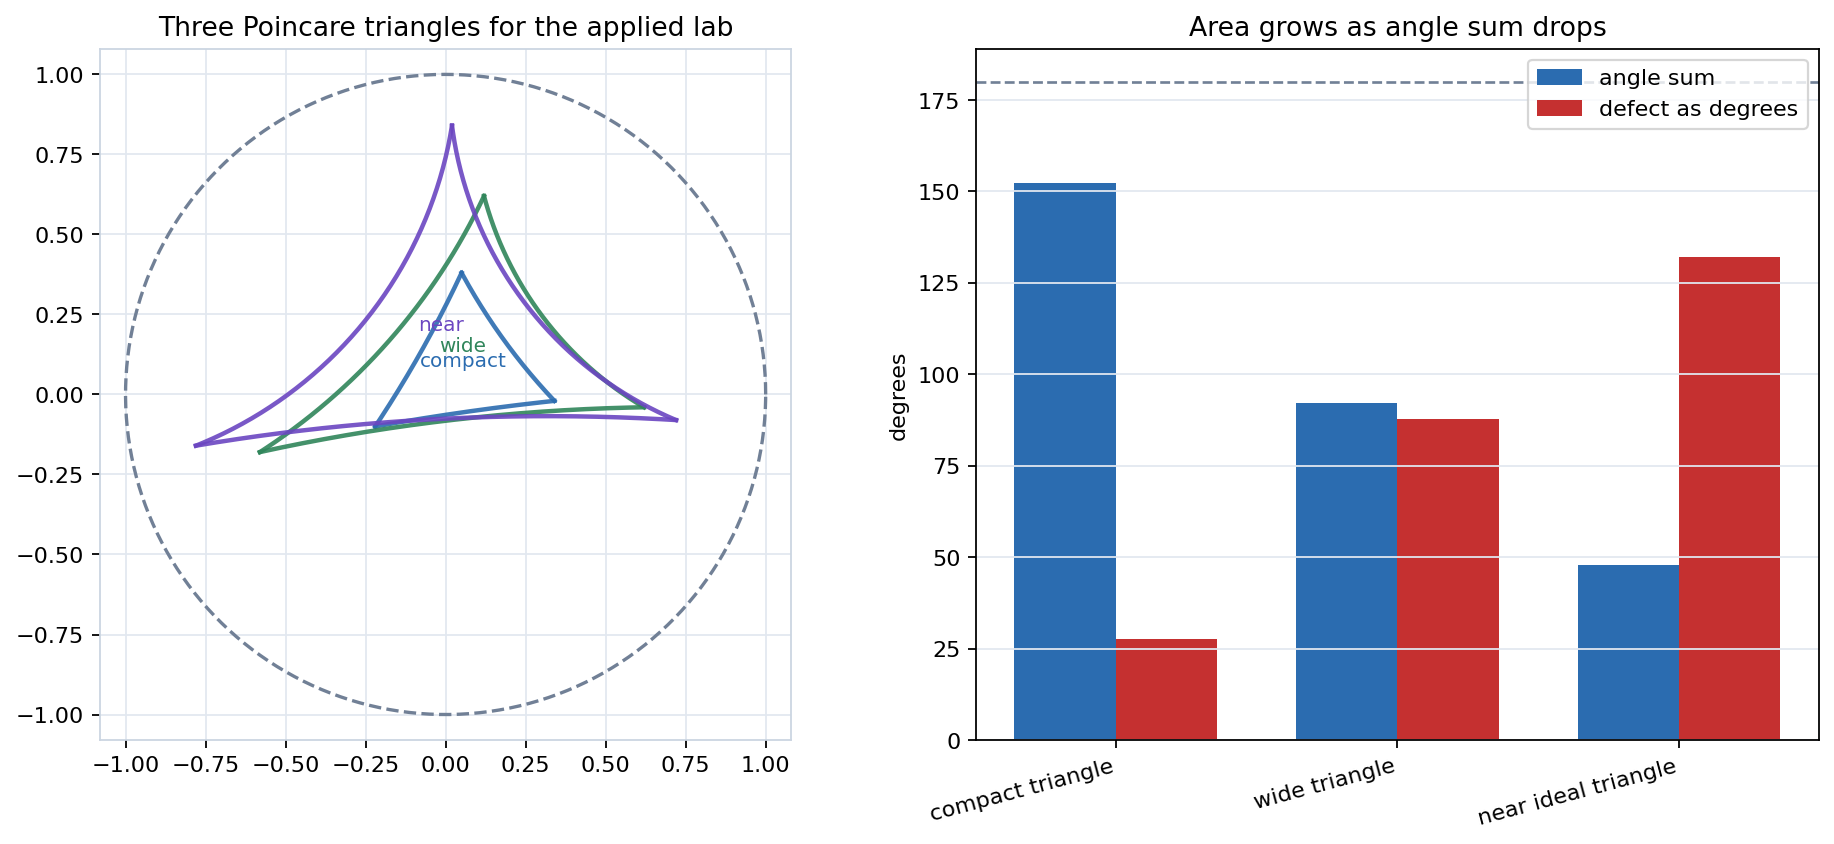

,triangle,a,b,c,A_deg,B_deg,C_deg,angle_sum_deg,area_defect,cosine_law_residual
0,compact triangle,1.083999,1.162392,1.171856,46.177084,52.650232,53.527008,152.354323,0.482508,2.220446e-16
1,wide triangle,2.232372,2.627480,2.833556,20.499057,31.545924,40.094477,92.139459,1.533456,1.065814e-14
2,near ideal triangle,3.694802,4.142315,3.986678,12.194456,19.303559,16.433439,47.931454,2.305031,1.172396e-13


In [7]:
lab_triangles = {
    "compact triangle": [np.array([-0.22, -0.10]), np.array([0.34, -0.02]), np.array([0.05, 0.38])],
    "wide triangle": [np.array([-0.58, -0.18]), np.array([0.62, -0.04]), np.array([0.12, 0.62])],
    "near ideal triangle": [np.array([-0.78, -0.16]), np.array([0.72, -0.08]), np.array([0.02, 0.84])],
}
lab_rows = []
for name, verts in lab_triangles.items():
    m = triangle_measure(verts)
    lab_rows.append({
        "triangle": name,
        "a": m["side_a"],
        "b": m["side_b"],
        "c": m["side_c"],
        "A_deg": math.degrees(m["angle_A"]),
        "B_deg": math.degrees(m["angle_B"]),
        "C_deg": math.degrees(m["angle_C"]),
        "angle_sum_deg": math.degrees(m["angle_sum"]),
        "area_defect": m["area_defect"],
        "cosine_law_residual": m["cosine_law_max_abs_residual"],
    })
lab_df = pd.DataFrame(lab_rows)
lab_csv_path = TABLES / "hyperbolic-triangle-lab.csv"
lab_df.to_csv(lab_csv_path, index=False)
record_artifact(lab_csv_path, "applied hyperbolic triangle lab table", min_bytes=128)

right_check = right_triangle_check()
right_checks_path = save_json(right_check, UNIT, "checks", "right-triangle-checks.json", root=ARTIFACT_ROOT)
record_artifact(right_checks_path, "hyperbolic right-triangle trigonometry checks", min_bytes=256)

triangle_checks = {
    "triangles": lab_rows,
    "max_cosine_law_residual": float(lab_df["cosine_law_residual"].abs().max()),
    "min_area_defect": float(lab_df["area_defect"].min()),
    "right_triangle": {
        "right_angle_error": right_check["right_angle_error"],
        "pythagorean_residual": right_check["pythagorean_residual"],
        "sine_rule_residual": right_check["sine_rule_residual"],
    },
}
triangle_checks_path = save_json(triangle_checks, UNIT, "checks", "hyperbolic-triangle-checks.json", root=ARTIFACT_ROOT)
record_artifact(triangle_checks_path, "hyperbolic triangle area and trigonometry checks", min_bytes=512)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
ax = axes[0]
boundary = unit_boundary()
ax.plot(boundary[:, 0], boundary[:, 1], color=PALETTE["gray"], linestyle="--")
colors = [PALETTE["blue"], PALETTE["green"], PALETTE["purple"]]
for (name, verts), color in zip(lab_triangles.items(), colors):
    for a, b in [(verts[0], verts[1]), (verts[1], verts[2]), (verts[2], verts[0])]:
        arc = geodesic_arc_points(a, b, samples=160)
        ax.plot(arc[:, 0], arc[:, 1], color=color, linewidth=2.0, alpha=0.9)
    centroid = np.mean(np.vstack(verts), axis=0)
    ax.text(centroid[0], centroid[1], name.split()[0], color=color, fontsize=9, ha="center")
ax.set_title("Three Poincare triangles for the applied lab")
set_equal_axes(ax)
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-1.08, 1.08)

ax = axes[1]
order = np.arange(len(lab_df))
ax.bar(order - 0.18, lab_df["angle_sum_deg"], width=0.36, color=PALETTE["blue"], label="angle sum")
ax.bar(order + 0.18, np.degrees(lab_df["area_defect"]), width=0.36, color=PALETTE["red"], label="defect as degrees")
ax.axhline(180, linestyle="--", color=PALETTE["gray"], linewidth=1.2)
ax.set_xticks(order, lab_df["triangle"], rotation=15, ha="right")
ax.set_ylabel("degrees")
ax.set_title("Area grows as angle sum drops")
ax.grid(axis="y", color="#e2e8f0")
ax.legend()
fig.tight_layout()
triangle_figure_path = save_matplotlib(fig, UNIT, "figures", "hyperbolic-triangle-area-trig.png", root=ARTIFACT_ROOT)
plt.close(fig)
record_artifact(triangle_figure_path, "hyperbolic triangle area and trigonometry visual")

display_artifact(triangle_figure_path, width=980)
lab_df


## Applied Lab: Change the Model Data, Not the Theory

The lab table is intentionally small and reproducible. The rows are not examples to memorize; they are checkpoints for experiments. Move any vertex inside the unit disk, re-run the section, and inspect which residuals remain small. If a point is pushed outside the disk, the model assumptions fail before the theorem checks do.

The target behavior is:

- the angle sum is always below `180` degrees for these hyperbolic triangles;
- the defect is positive and equals the curvature `-1` area in this normalization;
- the hyperbolic cosine law residual is near machine precision;
- the right-triangle residuals are near machine precision.


In [8]:
applied_lab = lab_df.copy()
applied_lab["inspection_target"] = [
    "compare a small hyperbolic triangle with Euclidean intuition",
    "watch angle sum drop as vertices spread outward",
    "see an almost ideal triangle approach a large defect",
]
applied_lab_path = TABLES / "applied-lab-triangles.csv"
applied_lab.to_csv(applied_lab_path, index=False)
record_artifact(applied_lab_path, "applied lab triangle inspection table", min_bytes=128)
applied_lab


,triangle,a,b,c,A_deg,B_deg,C_deg,angle_sum_deg,area_defect,cosine_law_residual,inspection_target
0,compact triangle,1.083999,1.162392,1.171856,46.177084,52.650232,53.527008,152.354323,0.482508,2.220446e-16,compare a small hyperbolic triangle with Eucli...
1,wide triangle,2.232372,2.627480,2.833556,20.499057,31.545924,40.094477,92.139459,1.533456,1.065814e-14,watch angle sum drop as vertices spread outward
2,near ideal triangle,3.694802,4.142315,3.986678,12.194456,19.303559,16.433439,47.931454,2.305031,1.172396e-13,see an almost ideal triangle approach a large ...


## Final Sanity Checks

The final cell checks the chapter invariants, artifact integrity, and numeric tolerances. It also writes compact JSON summaries under the chapter artifact subtree so another worker can audit the pass without opening the notebook outputs.


In [9]:
visual_checks = {
    **direct_visual_checks,
    **interactive_geodesic_checks,
    **ends_checks,
    "neutral_min_area_defect": float(neutral_df["area_by_defect"].min()),
    "lab_max_cosine_law_residual": float(lab_df["cosine_law_residual"].abs().max()),
    "lab_min_area_defect": float(lab_df["area_defect"].min()),
    "right_triangle_right_angle_error": right_check["right_angle_error"],
    "right_triangle_pythagorean_residual": right_check["pythagorean_residual"],
    "right_triangle_sine_rule_residual": right_check["sine_rule_residual"],
}

assert visual_checks["inversion_involution_error"] < 1e-12
assert visual_checks["inversion_product_error"] < 1e-12
assert visual_checks["geodesic_orthogonality_max"] < 1e-10
assert visual_checks["cayley_distance_error"] < 1e-10
assert visual_checks["angle_parallelism_error"] < 1e-12
assert visual_checks["vertical_distance_log_error"] < 1e-12
assert visual_checks["neutral_min_area_defect"] > 0
assert visual_checks["lab_min_area_defect"] > 0
assert visual_checks["lab_max_cosine_law_residual"] < 1e-10
assert visual_checks["right_triangle_right_angle_error"] < 1e-12
assert visual_checks["right_triangle_pythagorean_residual"] < 1e-10
assert visual_checks["right_triangle_sine_rule_residual"] < 1e-10

visual_checks_path = save_json(visual_checks, UNIT, "checks", "visual-checks.json", root=ARTIFACT_ROOT)
record_artifact(visual_checks_path, "chapter visual and invariant checks", min_bytes=512)

validated_artifacts = []
for record in artifact_records:
    artifact_path = BOOK_ROOT / record["path"]
    assert_artifact(artifact_path, min_bytes=64)
    assert artifact_path.resolve().is_relative_to(UNIT_ARTIFACT_ROOT.resolve())
    validated_artifacts.append({**record, "bytes": artifact_path.stat().st_size})

final_sanity = {
    "unit": UNIT,
    "source_span": source_span,
    "artifact_count": len(validated_artifacts),
    "artifacts": validated_artifacts,
    "checks": visual_checks,
    "libraries": {
        "Matplotlib": "static construction diagrams and defect ledgers",
        "Plotly": "standalone interactive geodesic and ends visuals",
        "NetworkX": "neutral-geometry proof-state dependency graph",
        "SymPy": "exact angle-of-parallelism identity scaffold",
        "NumPy/Pandas": "model computations and applied lab tables",
    },
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT)
assert_artifact(final_sanity_path, min_bytes=512)

pd.DataFrame([
    {"check": key, "value": value}
    for key, value in visual_checks.items()
    if isinstance(value, (int, float, str))
])


,check,value
0,inversion_involution_error,0.0
1,inversion_product_error,0.0
2,geodesic_orthogonality_max,0.0
3,cayley_roundtrip_error,0.0
4,cayley_distance_error,0.0
5,triangle_area_defect,1.494909
6,triangle_cosine_law_max_abs_residual,0.0
7,frame_count,15
8,max_orthogonality_residual,0.0
9,min_distance,2.266347


## Takeaways

- The parallel postulate is a model decision, not a visual habit. Neutral geometry postpones that decision long enough to expose what all branches share.
- Circle inversion is the Euclidean construction tool that makes Poincare geodesics concrete: disk lines are circles orthogonal to the ideal boundary.
- The disk and half-plane models agree through the Cayley transform. Their screen shapes differ, but their distances and geodesic predicates match.
- Ends are ideal boundary data. In the upper half-plane, endpoint arithmetic makes translations, dilations, and limiting parallels computationally visible.
- Hyperbolic area and trigonometry are measurable, not decorative. Angle defect is positive, the cosine law checks numerically, and right-triangle identities recover the chapter's `sinh`/`cosh` structure.
